## ***Lab Report 2***

### ***Part 1***

PDLS trials found: 10
DDLS trials found: 10


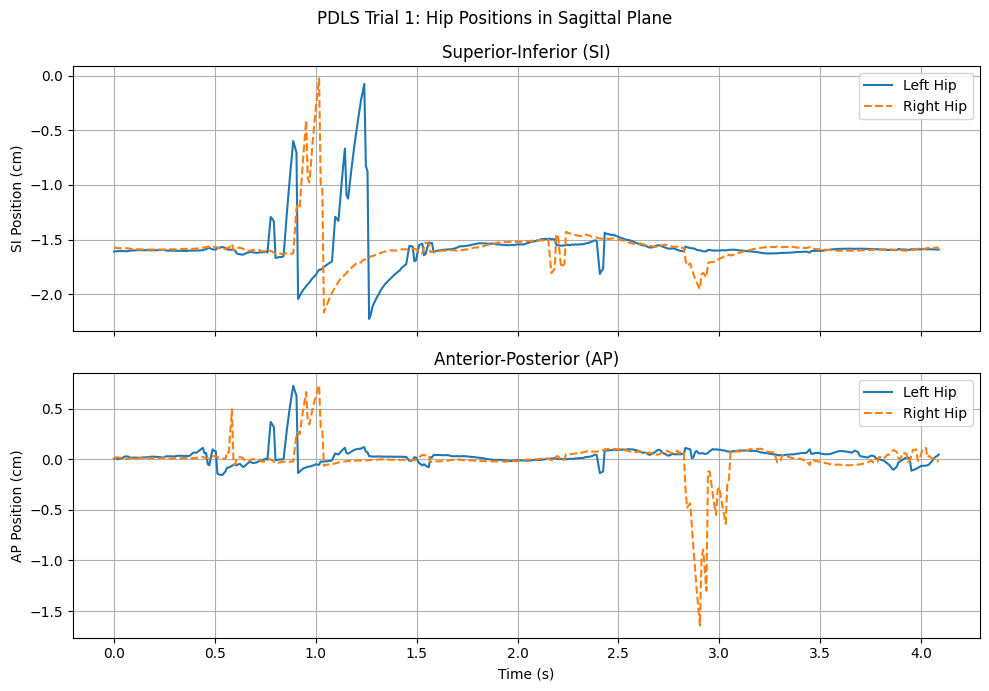

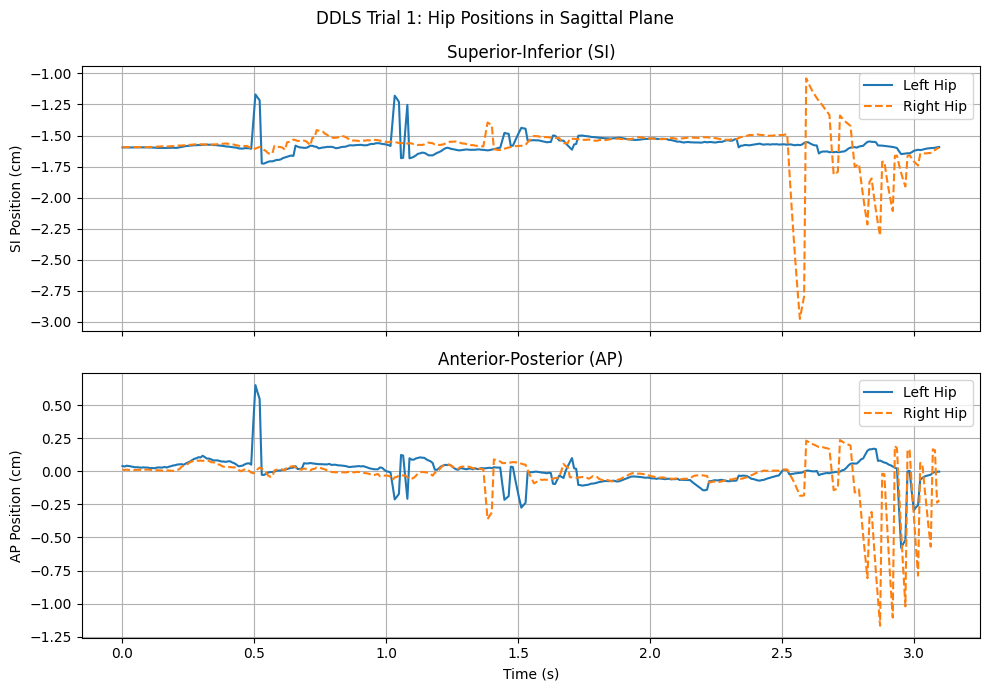


=== Peak Hip Displacement Statistics (cm) ===
Motion   Direction        Mean         SD
------------------------------------------
PDLS     SI               1.36       1.34
PDLS     ML               0.31       0.18
PDLS     AP               1.19       0.61

DDLS     SI               1.05       0.24
DDLS     ML               0.34       0.15
DDLS     AP               1.12       0.38



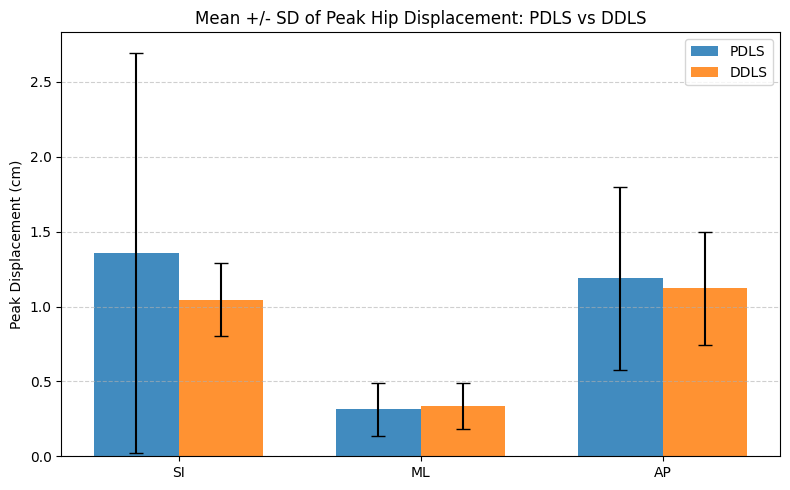


(d) Differences in means (PDLS vs DDLS):
- SI: lower in DDLS (PDLS=1.36, DDLS=1.05)
- ML: higher in DDLS (PDLS=0.31, DDLS=0.34)
- AP: lower in DDLS (PDLS=1.19, DDLS=1.12)

(e) Interpretation:
- Increased SI mean: larger vertical hip excursion (deeper squat).
- Increased ML mean: more side-to-side sway / asymmetry.
- Increased AP mean: more forward-backward excursion.
- Increased SD with similar mean: less consistency across trials (more variability).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os


def parse_bvh(filepath):
    """Parse BVH file into joint metadata and motion matrix."""
    with open(filepath, "r") as f:
        content = f.read()

    hier_part, motion_part = content.split("MOTION", 1)

    joint_data = {}
    col = 0
    current_joint = None

    for line in hier_part.splitlines():
        s = line.strip()
        if s.startswith("ROOT") or s.startswith("JOINT"):
            current_joint = s.split()[1]
        elif s.startswith("CHANNELS") and current_joint:
            parts = s.split()
            n_ch = int(parts[1])
            ch_names = parts[2:2 + n_ch]
            joint_data[current_joint] = {"channels": ch_names, "col_start": col}
            col += n_ch

    frame_time = None
    data_rows = []
    for line in motion_part.strip().splitlines():
        s = line.strip()
        if s.startswith("Frame Time:"):
            frame_time = float(s.split(":", 1)[1].strip())
        elif s and not s.startswith("Frames") and not s.startswith("Frame Time"):
            vals = list(map(float, s.split()))
            if vals:
                data_rows.append(vals)

    return joint_data, np.array(data_rows), frame_time


def get_pos(joint_data, motion, joint_name):
    """
    Axis mapping:
    Xposition -> ML
    Yposition -> SI
    Zposition -> AP
    """
    info = joint_data[joint_name]
    cs = info["col_start"]
    out = {}
    for i, ch in enumerate(info["channels"]):
        if ch in ("Xposition", "Yposition", "Zposition"):
            out[ch] = motion[:, cs + i]
    return out


def peak_displacements(files):
    """
    Peak displacement per trial = range (max-min),
    averaged between left and right hips.
    """
    si_peaks, ml_peaks, ap_peaks = [], [], []
    for fp in files:
        jd, mot, _ = parse_bvh(fp)
        left = get_pos(jd, mot, "LeftUpLeg")
        right = get_pos(jd, mot, "RightUpLeg")

        si_peaks.append((np.ptp(left["Yposition"]) + np.ptp(right["Yposition"])) / 2.0)
        ml_peaks.append((np.ptp(left["Xposition"]) + np.ptp(right["Xposition"])) / 2.0)
        ap_peaks.append((np.ptp(left["Zposition"]) + np.ptp(right["Zposition"])) / 2.0)

    return np.array(si_peaks), np.array(ml_peaks), np.array(ap_peaks)


def summarize(peaks):
    return {
        "SI_mean": np.mean(peaks[0]), "SI_std": np.std(peaks[0]),
        "ML_mean": np.mean(peaks[1]), "ML_std": np.std(peaks[1]),
        "AP_mean": np.mean(peaks[2]), "AP_std": np.std(peaks[2]),
    }


def print_comments(pdls_stats, ddls_stats):
    print("\n(d) Differences in means (PDLS vs DDLS):")
    for axis in ["SI", "ML", "AP"]:
        p = pdls_stats[f"{axis}_mean"]
        d = ddls_stats[f"{axis}_mean"]
        if d > p:
            trend = "higher in DDLS"
        elif d < p:
            trend = "lower in DDLS"
        else:
            trend = "the same"
        print(f"- {axis}: {trend} (PDLS={p:.2f}, DDLS={d:.2f})")

    print("\n(e) Interpretation:")
    print("- Increased SI mean: larger vertical hip excursion (deeper squat).")
    print("- Increased ML mean: more side-to-side sway / asymmetry.")
    print("- Increased AP mean: more forward-backward excursion.")
    print("- Increased SD with similar mean: less consistency across trials (more variability).")


# Motion 1 = PDLS, Motion 2 = DDLS
data_dir = "data"
pdls_files = sorted(glob.glob(os.path.join(data_dir, "motion_1_*.bvh")))
ddls_files = sorted(glob.glob(os.path.join(data_dir, "motion_2_*.bvh")))

print(f"PDLS trials found: {len(pdls_files)}")
print(f"DDLS trials found: {len(ddls_files)}")

# Units note:
# BVH has no enforced unit, but offsets suggest these are likely centimeters, not millimeters.
unit_label = "cm"

# (a) PDLS one trial, sagittal plane (SI and AP)
jd, mot, ft = parse_bvh(pdls_files[0])
t = np.arange(mot.shape[0]) * ft
L = get_pos(jd, mot, "LeftUpLeg")
R = get_pos(jd, mot, "RightUpLeg")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("PDLS Trial 1: Hip Positions in Sagittal Plane")

axes[0].plot(t, L["Yposition"], label="Left Hip", color="tab:blue")
axes[0].plot(t, R["Yposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, L["Zposition"], label="Left Hip", color="tab:blue")
axes[1].plot(t, R["Zposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# (b) DDLS one trial, sagittal plane (SI and AP)
jd2, mot2, ft2 = parse_bvh(ddls_files[0])
t2 = np.arange(mot2.shape[0]) * ft2
L2 = get_pos(jd2, mot2, "LeftUpLeg")
R2 = get_pos(jd2, mot2, "RightUpLeg")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("DDLS Trial 1: Hip Positions in Sagittal Plane")

axes[0].plot(t2, L2["Yposition"], label="Left Hip", color="tab:blue")
axes[0].plot(t2, R2["Yposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t2, L2["Zposition"], label="Left Hip", color="tab:blue")
axes[1].plot(t2, R2["Zposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# (c) Mean and SD of peak displacement over all 10 trials in SI, ML, AP
pdls_peaks = peak_displacements(pdls_files)
ddls_peaks = peak_displacements(ddls_files)

pdls_stats = summarize(pdls_peaks)
ddls_stats = summarize(ddls_peaks)

print(f"\n=== Peak Hip Displacement Statistics ({unit_label}) ===")
print(f"{'Motion':<8} {'Direction':<10} {'Mean':>10} {'SD':>10}")
print("-" * 42)

for name, stats in [("PDLS", pdls_stats), ("DDLS", ddls_stats)]:
    for axis in ["SI", "ML", "AP"]:
        print(f"{name:<8} {axis:<10} {stats[f'{axis}_mean']:>10.2f} {stats[f'{axis}_std']:>10.2f}")
    print()

# Bar chart summary
directions = ["SI", "ML", "AP"]
pdls_means = [pdls_stats["SI_mean"], pdls_stats["ML_mean"], pdls_stats["AP_mean"]]
pdls_stds = [pdls_stats["SI_std"], pdls_stats["ML_std"], pdls_stats["AP_std"]]
ddls_means = [ddls_stats["SI_mean"], ddls_stats["ML_mean"], ddls_stats["AP_mean"]]
ddls_stds = [ddls_stats["SI_std"], ddls_stats["ML_std"], ddls_stats["AP_std"]]

x = np.arange(len(directions))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, pdls_means, w, yerr=pdls_stds, capsize=5, label="PDLS", color="tab:blue", alpha=0.85)
ax.bar(x + w / 2, ddls_means, w, yerr=ddls_stds, capsize=5, label="DDLS", color="tab:orange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(directions)
ax.set_ylabel(f"Peak Displacement ({unit_label})")
ax.set_title("Mean +/- SD of Peak Hip Displacement: PDLS vs DDLS")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# (d) + (e) automatic comments
print_comments(pdls_stats, ddls_stats)